In [3]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

Повторим рассчет матрицы переходов из Задания 5:

In [5]:
record = SeqIO.read("chr1.fasta", "fasta") #буду всё также работать с первой хромосомой человека
seq = str(record.seq).upper()
seq = seq[10000:20000] #возьмем вторые 10000 нуклеотидов

In [6]:
nucleotides = ['A', 'C', 'G', 'T']
n = len(nucleotides)
counts = np.zeros((n, n), dtype=int)

for i in range(len(seq)-1):
    if seq[i] in nucleotides and seq[i+1] in nucleotides:
        from_idx = nucleotides.index(seq[i])
        to_idx = nucleotides.index(seq[i+1])
        counts[from_idx, to_idx] += 1

P = counts / counts.sum(axis=1, keepdims=True)

print("Матрица переходов P:")
print('По строкам - направление "от" (from)')
print('По столбцам - направление "к" (to) ')
print("     A      C      G      T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}  {P[i,0]:.4f} {P[i,1]:.4f} {P[i,2]:.4f} {P[i,3]:.4f}")

Матрица переходов P:
По строкам - направление "от" (from)
По столбцам - направление "к" (to) 
     A      C      G      T
A  0.2237 0.2479 0.3898 0.1385
C  0.2507 0.3600 0.1014 0.2880
G  0.1969 0.3002 0.3406 0.1623
T  0.1363 0.2770 0.3963 0.1905


Возведем матрицу $P$ в степени:

In [7]:
from numpy.linalg import matrix_power

P_k = {}
diffs = []
k_values = range(1, 1001)

prev_P = P.copy()
for k in k_values:
    P_k[k] = matrix_power(P, k)
    if k > 1:
        diff = np.linalg.norm(P_k[k] - prev_P, 'fro')
        diffs.append(diff)
    prev_P = P_k[k].copy()

In [8]:
for i in [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 40, 50, 70, 80, 90, 100, 150, 200, 300, 400, 500, 750, 1000]:
    P__k = np.linalg.matrix_power(P, k)
    print(f'Матрица P^{i}:')
    print(f"  {'':4}", ''.join(f'{s:>10}' for s in nucleotides))
    for i, row in enumerate(P__k):
        print(f"  {nucleotides[i]}:  ", '  '.join(f'{v:.6f}' for v in row))

Матрица P^1:
                A         C         G         T
  A:   0.206521  0.302830  0.289529  0.201120
  C:   0.206521  0.302830  0.289529  0.201120
  G:   0.206521  0.302830  0.289529  0.201120
  T:   0.206521  0.302830  0.289529  0.201120
Матрица P^2:
                A         C         G         T
  A:   0.206521  0.302830  0.289529  0.201120
  C:   0.206521  0.302830  0.289529  0.201120
  G:   0.206521  0.302830  0.289529  0.201120
  T:   0.206521  0.302830  0.289529  0.201120
Матрица P^3:
                A         C         G         T
  A:   0.206521  0.302830  0.289529  0.201120
  C:   0.206521  0.302830  0.289529  0.201120
  G:   0.206521  0.302830  0.289529  0.201120
  T:   0.206521  0.302830  0.289529  0.201120
Матрица P^4:
                A         C         G         T
  A:   0.206521  0.302830  0.289529  0.201120
  C:   0.206521  0.302830  0.289529  0.201120
  G:   0.206521  0.302830  0.289529  0.201120
  T:   0.206521  0.302830  0.289529  0.201120
Матрица P^5:
       

Построим график "стабилизации" матрицы:

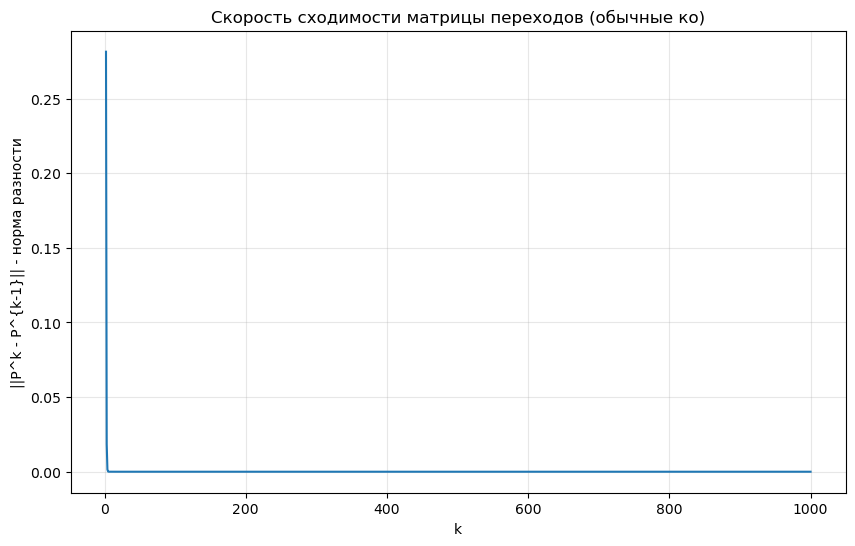

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 1001), diffs)
plt.xlabel('k')
plt.ylabel('||P^k - P^{k-1}|| - норма разности')
plt.title('Скорость сходимости матрицы переходов (обычные ко)')
plt.grid(True, alpha=0.3)
plt.show()

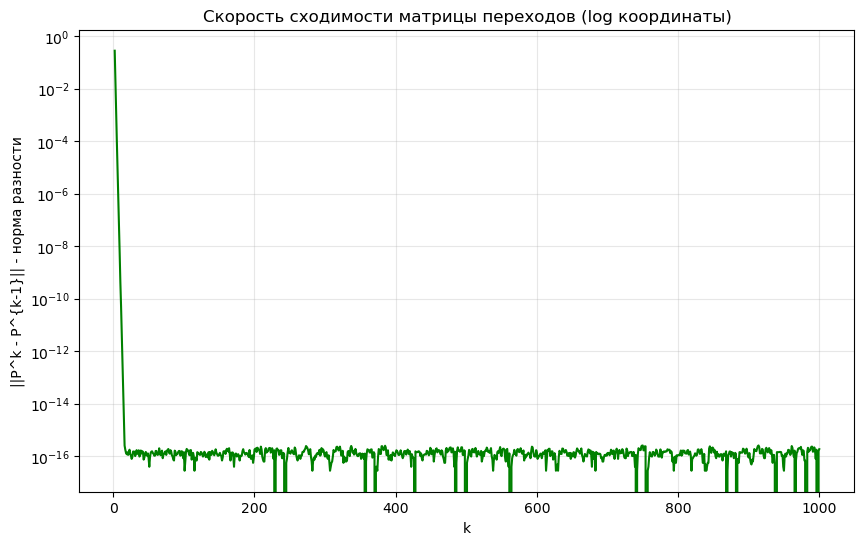

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 1001), diffs, color='g')
plt.xlabel('k')
plt.ylabel('||P^k - P^{k-1}|| - норма разности')
plt.title('Скорость сходимости матрицы переходов (log координаты)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

Как можно заметить, матрица очень быстро стабилизируется.

Выведем стационарное распр-е из Задания 5:

In [12]:
eigenvals, eigenvecs = np.linalg.eig(P.T)
stationary = eigenvecs[:, np.isclose(eigenvals, 1)].real
stationary = stationary / stationary.sum()
stationary = stationary.flatten()

print("Стационарное распределение π:")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: {stationary[i]:.6f}")

Стационарное распределение π:
A: 0.206521
C: 0.302830
G: 0.289529
T: 0.201120


Сравним строки матрицы $P^{1000}$ со стационарным распр-ем $\pi$:

In [14]:
P_1000 = P_k[1000]

print("\nМатрица P^1000:")
print("     A      C      G      T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}  {P_1000[i,0]:.6f} {P_1000[i,1]:.6f} {P_1000[i,2]:.6f} {P_1000[i,3]:.6f}")


Матрица P^1000:
     A      C      G      T
A  0.206521 0.302830 0.289529 0.201120
C  0.206521 0.302830 0.289529 0.201120
G  0.206521 0.302830 0.289529 0.201120
T  0.206521 0.302830 0.289529 0.201120


Как можно отметить, все строки матрицы $P^{1000}$ и правда сиали одинаковы. А значения столбцов равны значениям стационарного распр-я $\pi$.

Можем также визуализировать сходимость строк:

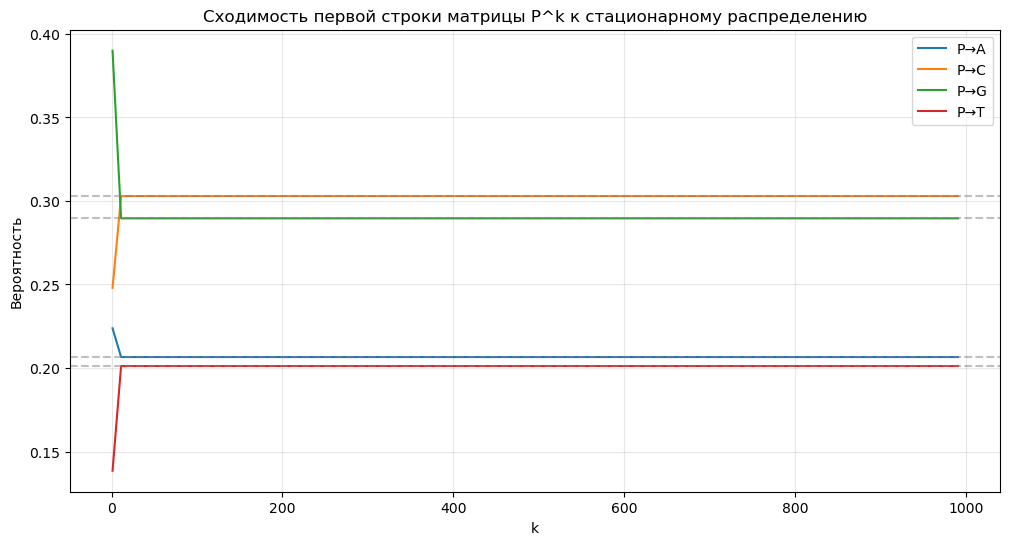

In [16]:
first_row_evolution = []
for k in range(1, 1001, 10):  # берем каждую 10-ю степень
    first_row_evolution.append(P_k[k][0])

first_row_evolution = np.array(first_row_evolution)

plt.figure(figsize=(12, 6))
for i, nuc in enumerate(nucleotides):
    plt.plot(range(1, 1001, 10), first_row_evolution[:, i], label=f'P→{nuc}')

plt.axhline(y=stationary[0], color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=stationary[1], color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=stationary[2], color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=stationary[3], color='gray', linestyle='--', alpha=0.5)

plt.xlabel('k')
plt.ylabel('Вероятность')
plt.title('Сходимость первой строки матрицы P^k к стационарному распределению')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()